In [1]:
# Import necessary libraries
import numpy as np
import matplotlib.pyplot as plt
from sklearn.metrics import r2_score

In [2]:
# Generate random data for polynomial regression
np.random.seed(2)

pageSpeeds = np.random.normal(3.0, 1.0, 1000)
purchaseAmount = np.random.normal(50.0, 10.0, 1000) / pageSpeeds

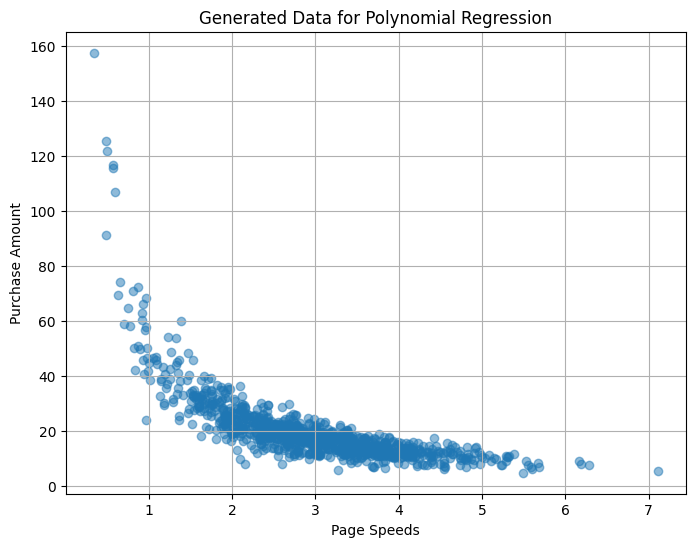

In [3]:
# Create a scatter plot of the data
plt.figure(figsize=(8, 6))
plt.scatter(pageSpeeds, purchaseAmount, alpha=0.5)
plt.title("Generated Data for Polynomial Regression")
plt.xlabel("Page Speeds")
plt.ylabel("Purchase Amount")
plt.grid(True)
plt.show()

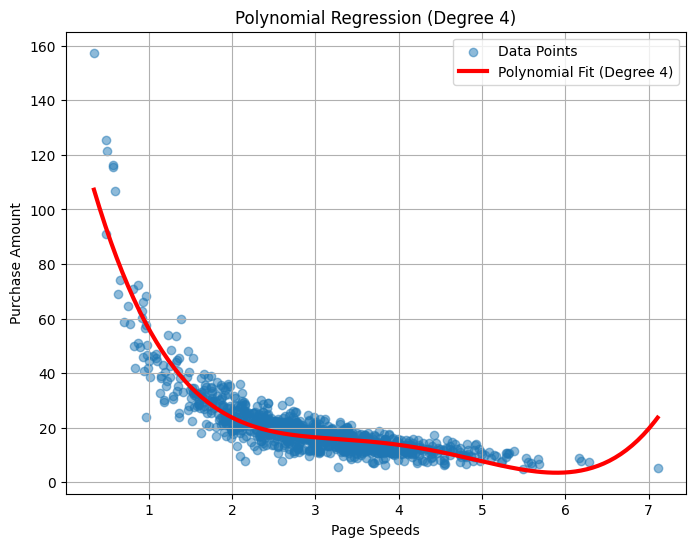

In [4]:
# Degree of the polynomial
x = np.array(pageSpeeds)
y = np.array(purchaseAmount)

p4 = np.poly1d(np.polyfit(x, y, 4))

xp = np.linspace(x.min(), x.max(), 200)

plt.figure(figsize=(8, 6))
plt.scatter(x, y, alpha=0.5, label='Data Points')
plt.plot(xp, p4(xp), color='red', linewidth=3, label='Polynomial Fit (Degree 4)')
plt.title(f"Polynomial Regression (Degree 4)")
plt.xlabel("Page Speeds")
plt.ylabel("Purchase Amount")
plt.grid(True)
plt.legend()
plt.show()

In [5]:
# Evaluate the model using R-squared
r2 = r2_score(y, p4(x))
print(f"R-squared for Polynomial Regression (Degree 4): {r2:.4f}")

R-squared for Polynomial Regression (Degree 4): 0.8294


In [8]:
# Compare different polynomial degrees
degrees = [2, 3, 4, 5, 6, 7]

print("Evaluating Polynomial Degrees:")
print("-"*30)

best_degree = None
best_r2 = -999

for degree in degrees:

    model = np.poly1d(np.polyfit(x, y, degree))
    prediction = model(x)
    score = r2_score(y, prediction)

    print(f"Degree {degree}: R² = {score:.4f}")

    if score > best_r2:
        best_r2 = score
        best_degree = degree

print("\nBest Polynomial Degree:", best_degree)
print("Best R²:", best_r2)

Evaluating Polynomial Degrees:
------------------------------
Degree 2: R² = 0.6927
Degree 3: R² = 0.7842
Degree 4: R² = 0.8294
Degree 5: R² = 0.8554
Degree 6: R² = 0.8701
Degree 7: R² = 0.8778

Best Polynomial Degree: 7
Best R²: 0.8778369781712095


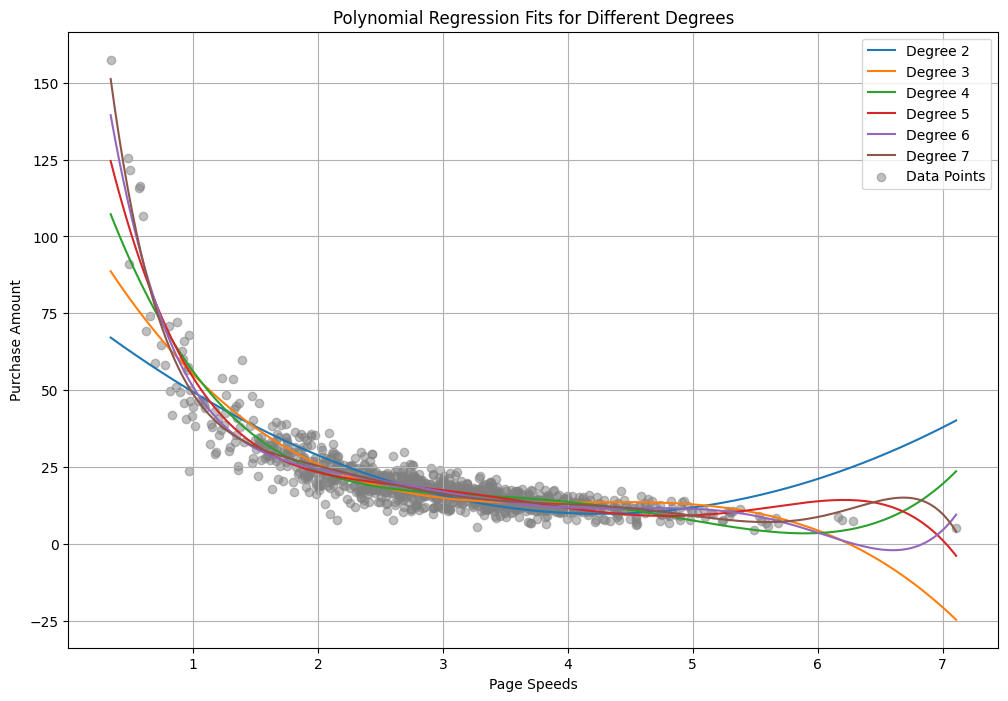

In [9]:
# Visualize all polynomial fits
plt.figure(figsize=(12, 8))
for degree in degrees:
    model = np.poly1d(np.polyfit(x, y, degree))
    xp = np.linspace(x.min(), x.max(), 200)
    plt.plot(xp, model(xp), label=f'Degree {degree}')

plt.scatter(x, y, alpha=0.5, color='gray', label='Data Points')
plt.title("Polynomial Regression Fits for Different Degrees")
plt.xlabel("Page Speeds")
plt.ylabel("Purchase Amount")
plt.grid(True)
plt.legend()
plt.show()